# Inferencia Estadística Multigrupo: Análisis de Varianza (ANOVA de 1 factor) y Pruebas Post-Hoc (Tukey)-Grupo A-U3

# Tarea 1

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Ejemplo: Tiempos de respuesta (ping) de 3 algoritmos

np.random.seed(42)

grupo_A = np.random.normal(loc=45.0, scale=5.0, size=30)
grupo_B = np.random.normal(loc=46.5, scale=4.8, size=30)
grupo_C = np.random.normal(loc=52.0, scale=5.5, size=30)
stat_f, p_val_f = f_oneway(grupo_A, grupo_B, grupo_C)

print(f"Estadístico F: {stat_f:.4f} | Valor-p: {p_val_f:.4e}")

Estadístico F: 22.6087 | Valor-p: 1.2389e-08


# Tarea 2

In [ ]:
import pandas as pd
from scipy import stats

nombres_columnas = ["Fecha", "Tipo", "Emisor", "Cantidad", "Valor_Nominal",
                    "Precio", "Valor_Nominal_Total", "Monto_Efectivo",
                    "Casa_Origen", "Casa_Destino", "Bolsa"]

df = pd.read_csv("BVG_Acciones_export.csv", names=nombres_columnas, skiprows=1)

df['Precio'] = pd.to_numeric(df['Precio'], errors='coerce')
df = df.dropna(subset=['Precio', 'Emisor'])

def categorizar_sector(emisor):
    emisor = emisor.upper()
    if "BANCO" in emisor:
        return "Bancario"
    elif any(keyword in emisor for keyword in ["INDUSTRIAL", "CERVECERIA", "HOLCIM", "SURPAPEL"]):
        return "Industrial"
    elif "FAVORITA" in emisor:
        return "Comercial"
    else:
        return "Otros"

df['Sector'] = df['Emisor'].apply(categorizar_sector)

# Segmentación de Grupos
grupo_bancos = df[df['Sector'] == 'Bancario']['Precio']
grupo_industrial = df[df['Sector'] == 'Industrial']['Precio']
grupo_comercial = df[df['Sector'] == 'Comercial']['Precio']

# Ejecución del ANOVA (f_oneway)
f_stat, p_value = stats.f_oneway(grupo_bancos, grupo_industrial, grupo_comercial)

alpha = 0.05

print("--- RESULTADOS DEL ANÁLISIS ANOVA ---")
print(f"Sectores Analizados: Bancario (n={len(grupo_bancos)}), Industrial (n={len(grupo_industrial)}), Comercial (n={len(grupo_comercial)})")
print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor P (p-value): {p_value:.4f}")
print("-" * 38)

if p_value <= alpha:
    print("DICTAMEN: SE RECHAZA LA HIPÓTESIS NULA (Ho).")
    print("CONCLUSIÓN (H1): Existen diferencias significativas entre los precios promedio de los sectores.")
else:
    print("DICTAMEN: NO SE RECHAZA LA HIPÓTESIS NULA (Ho).")
    print("CONCLUSIÓN: No existe evidencia suficiente para afirmar que los promedios de precios son distintos.")


--- RESULTADOS DEL ANÁLISIS ANOVA ---
Sectores Analizados: Bancario (n=7108), Industrial (n=2079), Comercial (n=14881)
Estadístico F: 4786.1322
Valor P (p-value): 0.0000
--------------------------------------
DICTAMEN: SE RECHAZA LA HIPÓTESIS NULA (Ho).
CONCLUSIÓN (H1): Existen diferencias significativas entre los precios promedio de los sectores.


### ¿El ANOVA sugiere que existen diferencias significativas entre los niveles? ¿Es necesario investigar más a fondo?
### El resultado del ANOVA rechaza H0 y nos dice que hay diferencias significativas entre las medias de los grupos comparados. En otras palabras, existen diferencias significativas entre los precios promedio de los sectores. Por lo cual se tendría que, ante la evidencia, ejecutar una investigación más a fondo para saber qué sectores muestran diferencias entre sí, podemos hacer esto con la ayuda de Post-Hoc de Tukey. También podriamos de paso saber si las varianzas de los grupos son iguales, con el test de Levene, y entonces llevar a cabo el uso de otras herramientas estadísticas.

# Tarea 3


--- RESULTADOS PRUEBA POST-HOC (TUKEY) ---
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1    group2   meandiff p-adj  lower    upper   reject
------------------------------------------------------------
 Bancario  Comercial  -12.086   0.0 -12.7207 -11.4513   True
 Bancario Industrial  29.3386   0.0   28.241  30.4361   True
Comercial Industrial  41.4246   0.0  40.3939  42.4552   True
------------------------------------------------------------


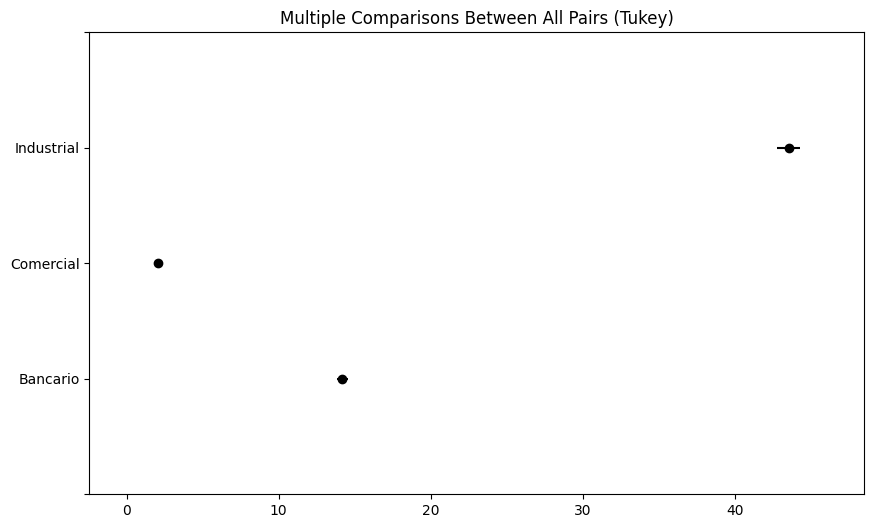

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import numpy as np

datos_combinados = pd.DataFrame({'Valor': np.concatenate([grupo_bancos.values, grupo_industrial.values, grupo_comercial.values]),
    'Grupo': (['Bancario'] * len(grupo_bancos)) + (['Industrial'] * len(grupo_industrial)) + (['Comercial'] * len(grupo_comercial))})

tukey = pairwise_tukeyhsd(endog=datos_combinados['Valor'],groups=datos_combinados['Grupo'],alpha=0.05)

print("\n--- RESULTADOS PRUEBA POST-HOC (TUKEY) ---")
print(tukey)

tukey.plot_simultaneous()
plt.show()

### Como podemos ver, todos los pares de grupos difieren entre sí. Esto se debe a que tienen medias muy diferentes entre sí.

# Preguntas de Control

### 1.Utilice scipy.stats.levene para verificar la igualdad de varianzas.
### 2.Discusión: Si el supuesto de homocedasticidad se viola, ¿qué alternativa no paramétrica (ej. Kruskal-Wallis) sería adecuada?


In [ ]:
# Verificación de Igualdad de Varianzas con Test de Levene
# Ho: Las varianzas son iguales
# H1: Al menos una varianza es distinta
stat_levene, p_levene = stats.levene(grupo_bancos, grupo_industrial, grupo_comercial)

alpha = 0.05

print("--- RESULTADOS DEL TEST DE LEVENE ---")
print(f"Estadístico W: {stat_levene:.4f}")
print(f"Valor P (p-value): {p_levene:.4f}")
print("-" * 38)


--- RESULTADOS DEL TEST DE LEVENE ---
Estadístico W: 1737.2797
Valor P (p-value): 0.0000
--------------------------------------


### El valor p del test de Levene es menor a la significancia establecida, por lo que rechazamos la hipótesis nula de igualdad de varianzas. Esto significa que las varianzas de los precios entre los sectores (Bancario, Industrial, Comercial) son significativamente diferentes.

### Dado que el supuesto de homocedasticidad se viola, una alternativa adecuada es la prueba de Kruskal-Wallis. Esta está preparada para comparar tres o más grupos independientes sin asumir normalidad en la distribución de los datos ni una igualdad de varianzas, permitiéndonos obtener información de una manera más segura.

# Prueba de Kruskal-Wallis

In [ ]:
import pandas as pd
from scipy import stats

nombres_columnas = ["Fecha", "Tipo", "Emisor", "Cantidad", "Valor_Nominal",
                    "Precio", "Valor_Nominal_Total", "Monto_Efectivo",
                    "Casa_Origen", "Casa_Destino", "Bolsa"]

df = pd.read_csv("BVG_Acciones_export.csv", names=nombres_columnas, skiprows=1)
df['Precio'] = pd.to_numeric(df['Precio'], errors='coerce')
df = df.dropna(subset=['Precio', 'Emisor'])

def categorizar_sector(emisor):
    emisor = emisor.upper()
    if "BANCO" in emisor: return "Bancario"
    elif any(kw in emisor for kw in ["INDUSTRIAL", "CERVECERIA", "HOLCIM", "SURPAPEL"]): return "Industrial"
    elif "FAVORITA" in emisor: return "Comercial"
    else: return "Otros"

df['Sector'] = df['Emisor'].apply(categorizar_sector)

grupo_bancos = df[df['Sector'] == 'Bancario']['Precio']
grupo_industrial = df[df['Sector'] == 'Industrial']['Precio']
grupo_comercial = df[df['Sector'] == 'Comercial']['Precio']

# Ejecución de la prueba de Kruskal-Wallis
h_stat, p_value = stats.kruskal(grupo_bancos, grupo_industrial, grupo_comercial)

alpha = 0.05

print("--- RESULTADOS DE LA PRUEBA DE KRUSKAL-WALLIS ---")
print(f"Estadístico H: {h_stat:.4f}")
print(f"Valor P (p-value): {p_value:.4f}")
print("-" * 50)

if p_value <= alpha:
    print("DICTAMEN: SE RECHAZA LA HIPÓTESIS NULA (Ho).")
    print("CONCLUSIÓN (H1): Existen diferencias significativas entre las medianas de los sectores.")

else:
    print("DICTAMEN: NO SE RECHAZA LA HIPÓTESIS NULA (Ho).")
    print("CONCLUSIÓN: No hay evidencia suficiente para afirmar que las medianas son distintas.")


--- RESULTADOS DE LA PRUEBA DE KRUSKAL-WALLIS ---
Estadístico H: 6656.3850
Valor P (p-value): 0.0000
--------------------------------------------------
DICTAMEN: SE RECHAZA LA HIPÓTESIS NULA (Ho).
CONCLUSIÓN (H1): Existen diferencias significativas entre las medianas de los sectores.


# Conclusiones
### Dados los resultados obtenidos, el uso del ANOVA de un factor, la prueba Post-Hoc de Tukey y la implementación de la prueba de Levene resultan fundamentales. Estas herramientas permiten al estudiante o profesional comprender mejor la naturaleza de su conjunto de datos, las técnicas estadísticas aplicables y la fiabilidad de los resultados. En este análisis específico, respecto al dataset del grupo, hemos podido conocer cómo el mercado y sus precios se comportan en distintos sectores, y hemos identificado las herramientas estadísticas adecuadas para cada situación, considerando la naturaleza particular del dataset.
